# Tuning a Decision Tree Model

In this notebook, we will load the Titanic dataset, split it into training and test sets, and then tune a Decision Tree classifier using GridSearchCV. We'll evaluate the performance of the best model using classification metrics and visualize the resulting decision tree.

## **Step 1: Load and Inspect the Data**

We use the Titanic dataset available from seaborn, which includes details about passengers. This dataset is widely used for classification tasks.

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Fetch dataset
data = sns.load_dataset("titanic")

### **Step 2: Data Preprocessing**

Our next step is to prepare the data for modeling:

- **Encoding Categorical Variables:**
   Decision tree algorithms can handle numerical inputs, so we convert
   categorical variables (e.g., `sex`) into numeric format using one-hot encoding.

*Note: We use drop_first=True to avoid the dummy variable trap.*

In [2]:
# Encoding categorical variables
df = pd.get_dummies(data, columns=['sex'], drop_first=True) # Use drop_first = True to avoid "dummy trap"

# Define features and target
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']
X = df[features]
y = df["survived"]

# Preview the cleaned dataset
print(X.head())
print(y.head())

   pclass   age  sibsp  parch     fare  sex_male
0       3  22.0      1      0   7.2500      True
1       1  38.0      1      0  71.2833     False
2       3  26.0      0      0   7.9250     False
3       1  35.0      1      0  53.1000     False
4       3  35.0      0      0   8.0500      True
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


### **Step 3: Splitting the Data**

We split the dataset into training and testing sets. The training set is used to build the decision tree model, while the testing set is used to evaluate its performance.

In [3]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

### **Step 4: Train the Decision Tree Model**

We initialize and train a Decision Tree classifier.
**Why Decision Trees?**
- They are intuitive and easy to interpret.
- They capture non-linear relationships without needing feature scaling.

Here, we use default parameters, but tuning (e.g., max_depth, min_samples_split) can improve performance and prevent overfitting.

In [4]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train tree classification model
model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### **Step 5: Evaluate the Model**

We now assess our model’s performance on the test data using several metrics:

- **Accuracy:** The overall proportion of correct predictions.
- **Confusion Matrix:** Displays the number of correct and incorrect predictions.
- **Classification Report:** Provides precision, recall, and F1-score, which help in understanding performance per class.

Accuracy: 0.79


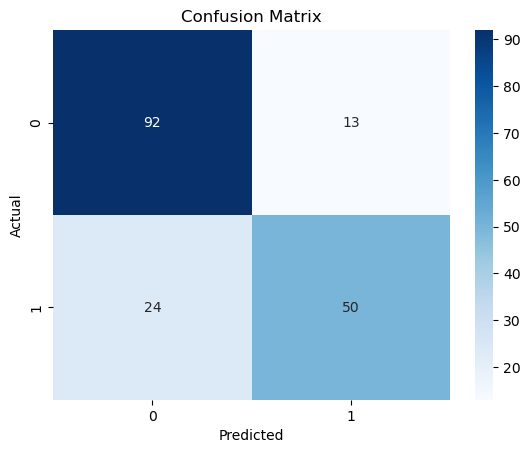

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       105
           1       0.79      0.68      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display classification report
print(classification_report(y_test, y_pred))

### **Step 6: Visualizing the Decision Tree**

One of the advantages of decision trees is their interpretability. We can visualize the tree structure using the graphviz library.
The visualization shows:
- Splitting criteria at each node.
- Feature names used for splits.
- Class distributions within the nodes.

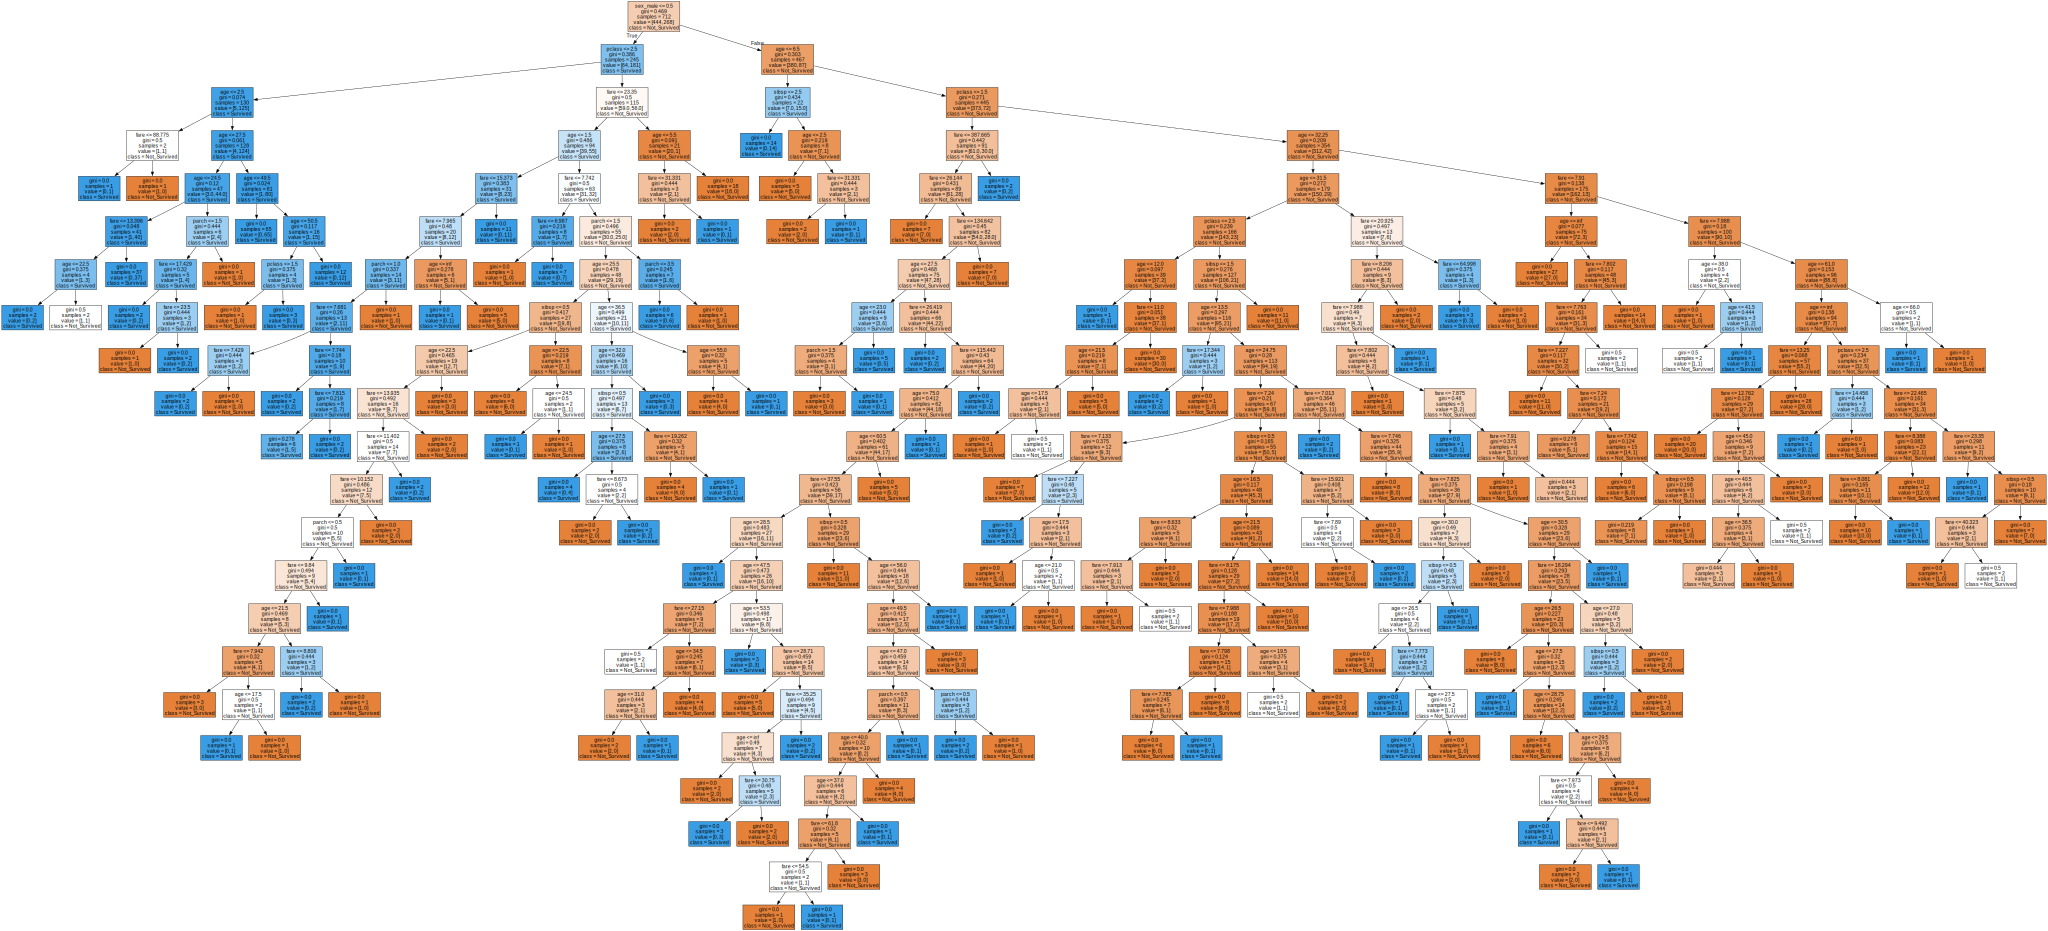

In [6]:
# Import graphviz and export the decision tree to dot format for visualization
import graphviz
from sklearn import tree  # Ensure to import the tree module from sklearn

dot_data = tree.export_graphviz(model, feature_names=X_train.columns,
                                class_names=["Not_Survived", "Survived"],
                                filled=True)

# Generate and display the decision tree graph
graph = graphviz.Source(dot_data)
graph

### **Step 7: Tuning the Decision Tree Model**

We'll perform hyperparameter tuning using GridSearchCV to find the best combination of parameters for the Decision Tree classifier. The parameters we will tune include:

- `criterion`: The function to measure the quality of a split.
- `max_depth`: Maximum depth of the tree
- `min_samples_split`: Minimum number of samples required to split an internal node
- `min_samples_leaf`: Minimum number of samples required to be at a leaf node
- `class_weight`: Adjusts for class imbalances

In [10]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV 

#DO NOT HAVE MORE BRANCHES THAN FEATURES!!!!!!!!!!

# Define the parameter grid for GridSearchCV
param_grid = {
    #Key Value pairs
    'criterion': ["gini", "entropy", "log_loss"],
    'max_depth': ["None", 2, 3, 4, 5, 6], 
    'min_samples_split': [2, 4, 6, 8], 
    'min_samples_leaf': [1, 2, 3, 4], 
    'class_weight': ["None", "balanced"]

}

# Initialize the Decision Tree classifier
dtree = DecisionTreeClassifier(random_state = 42)



# Set up GridSearchCV 
grid_search = GridSearchCV(
    estimator = dtree, #Reference model to use 
    param_grid = param_grid, #Import param_gram
    scoring = "f1", #Metric to tune for (i.e. We want our model to prioritize its F1-score)
    verbose = 3, #the amount of steps in the model being built 
    cv = 5, #slices up the data into smaller groups/folds 
) 

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 576 candidates, totalling 2880 fits
[CV 1/5] END class_weight=None, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=nan total time=   0.0s
[CV 2/5] END class_weight=None, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=nan total time=   0.0s
[CV 3/5] END class_weight=None, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=nan total time=   0.0s
[CV 4/5] END class_weight=None, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=nan total time=   0.0s
[CV 5/5] END class_weight=None, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=nan total time=   0.0s
[CV 1/5] END class_weight=None, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=4;, score=nan total time=   0.0s
[CV 2/5] END class_weight=None, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=4;, score=nan total time

/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1680 fits failed out of a total of 2880.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1440 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py", line 492, in _valida

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['None', 'balanced'], 'criterion': ['gini', 'entropy', ...], 'max_depth': ['None', 2, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [ ]:
grid_search.best_score_ #Avg. performance on the splits are 0.75


np.float64(0.7505455595489101)

### **Step 8: Evaluate the Tuned Model**

Using the best estimator from the grid search, we will evaluate its performance on the test set by generating a classification report and confusion matrix.

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Get the best estimator
best_dtree = grid_search.best_estimator_

# Predict on the test set
y_pred = best_dtree.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))
#The accurancy score reflects the score when we run our model on the entire dataset

# Print confusion matrix
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

[[92 13]
 [23 51]]


### **Step 9: Visualizing the Tuned Decision Tree**

One of the advantages of decision trees is their interpretability. We can visualize the tree structure using the graphviz library.
The visualization shows:
- Splitting criteria at each node.
- Feature names used for splits.
- Class distributions within the nodes.

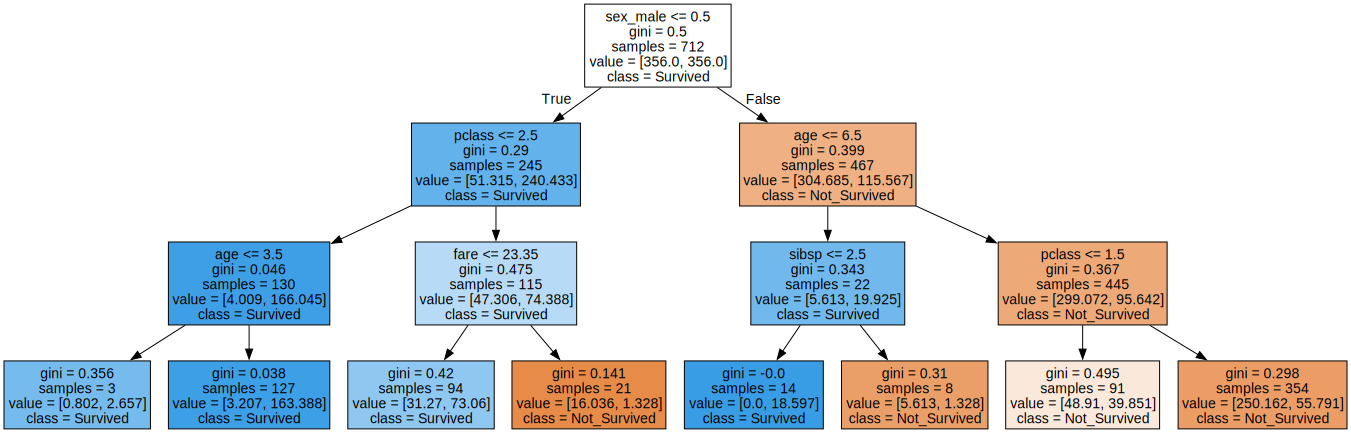

In [16]:
# Import graphviz and export the decision tree to dot format for visualization
import graphviz
from sklearn import tree  # Ensure to import the tree module from sklearn

dot_data = tree.export_graphviz(best_dtree,
                                feature_names=X_train.columns,
                                class_names=["Not_Survived", "Survived"],
                                filled=True)

# Generate and display the decision tree graph
graph = graphviz.Source(dot_data)
graph

**Using parameters, we can make a cleaner tree!! There are a lot less branches now. 

### **Step 10: ROC Curve and AUC Analysis**
The ROC (Receiver Operating Characteristic) curve helps evaluate the model's
performance across different classification thresholds:

- **ROC Curve:** Plots True Positive Rate (TPR) against False Positive Rate (FPR).
- **AUC (Area Under the Curve):** Summarizes the overall ability of the model to discriminate between classes.

Here, we calculate and plot the ROC curve along with the AUC score.

DT ROC AUC Score: 0.79
DT-Tuned ROC AUC Score: 0.85


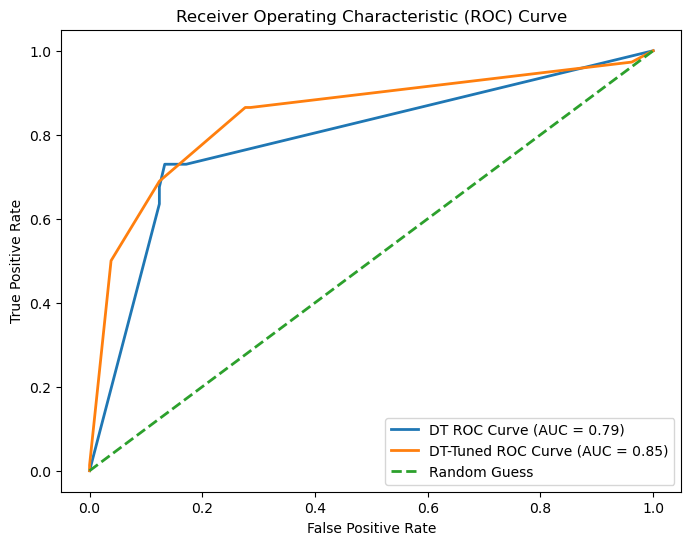

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get the predicted probabilities for the positive class (survived)
y_probs = model.predict_proba(X_test)[:, 1]

y_probs_tuned = best_dtree.predict_proba(X_test)[:, 1]

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_test, y_probs_tuned)


# Compute the Area Under the Curve (AUC) score
roc_auc = roc_auc_score(y_test, y_probs)
roc_auc_tuned = roc_auc_score(y_test, y_probs_tuned)

print(f"DT ROC AUC Score: {roc_auc:.2f}")
print(f"DT-Tuned ROC AUC Score: {roc_auc_tuned:.2f}")


# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'DT ROC Curve (AUC = {roc_auc:.2f})')
plt.plot(fpr_tuned, tpr_tuned, lw=2, label=f'DT-Tuned ROC Curve (AUC = {roc_auc_tuned:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess') # Plotting 50% line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()